# **Perceptron loss function**

Problem with perceptron trick
- It is hack and 99% it gives result and sometimes convergence wont happen and we wont know the best fitted line. 

Problems with the Perceptron Trick vs. The Need for Loss Functions

The **Perceptron Trick** is a quick heuristic (a "hack") rather than a mathematically rigorous optimizer. This leads to two major flaws that modern machine learning solves using **Loss Functions**.

---

### 1. The Convergence Problem (Noisy Data)
* **The Trick:** Modifies the boundary line based on a hard binary rule (correct vs. incorrect).
* **The Flaw:** It *only* converges if the data is 100% perfectly linearly separable. 
* **The Failure:** If the data has any noise, outliers, or overlap, the algorithm enters an **infinite loop**, bouncing back and forth endlessly without ever settling on a "good enough" line.

### 2. The Generalization Problem (The Lazy Line)
* **The Trick:** Stops updating the exact millisecond it finds *any* line that separates the classes.
* **The Flaw:** It doesn't care *where* the line is. It often draws the boundary dangerously close to one group of data points.
* **The Failure:** Zero **margin** means terrible generalization. New test data will easily cause misclassifications.

---

## Why Loss Functions Fix This

Instead of updating based on a crude "yes/no" trick, modern ML uses a continuous **Loss Function** (like Binary Cross-Entropy) and **Gradient Descent**:

#### A. Smooth Calculus instead of Step Functions
The Perceptron uses a rigid step function, which has a derivative of zero (making calculus impossible). Replacing it with a smooth function like **Sigmoid** gives us usable gradients:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

#### B. Optimizing for Confidence, Not Just Correctness
Using **Log Loss**, the model doesn't just ask "Am I right?". It asks "How confident am I?":
$$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

If a point is correctly classified but sits too close to the boundary, the loss function penalizes the low confidence. This forces the line to keep moving until it is **perfectly centered** between the classes, maximizing the safety margin.

#### C. Graceful Failure
When data overlaps, gradient descent doesn't loop infinitely. It simply finds the mathematical sweet spot where total error is minimized, giving you the absolute **best-fitted line**.

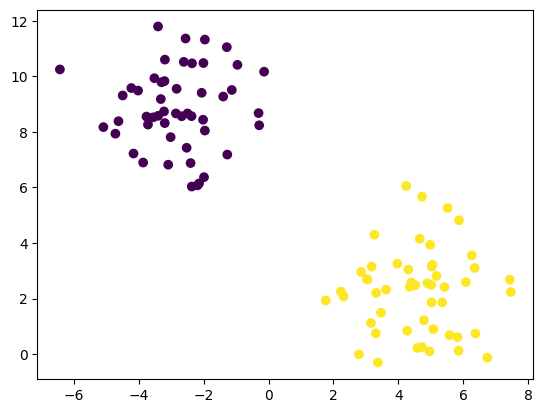

In [48]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=100,
    centers=2,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()
y = np.where(y == 0, -1, 1)

In [49]:
def perceptron(X, y):
    w1 = w2 = b = 1
    lr = 0.1

    for j in range(1000):
        for i in range(X.shape[0]):

            z = w1 * X[i][0] + w2 * X[i][1] + b

            if z * y[i] <= 0:
                w1 = w1 + lr * y[i] * X[i][0]
                w2 = w2 + lr * y[i] * X[i][1]
                b = b + lr * y[i]

    return w1, w2, b

In [50]:
w1, w2, b = perceptron(X, y)

m = -(w1 / w2)
c = -(b / w2)

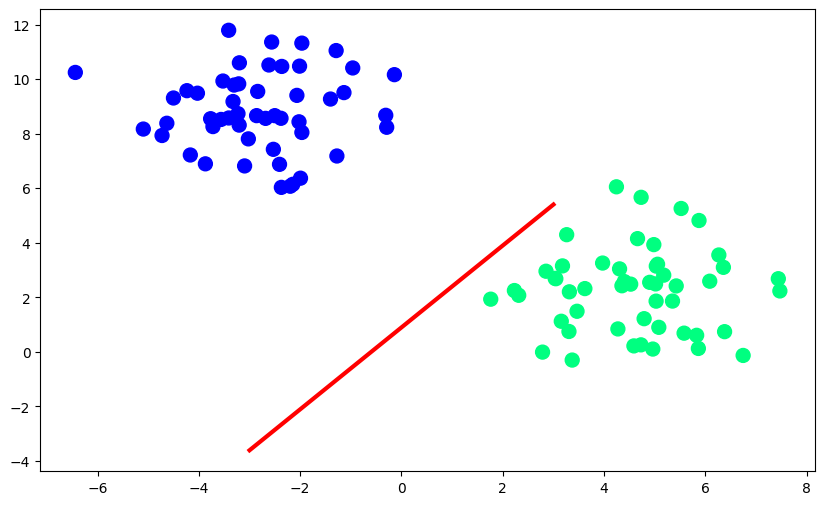

In [51]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color="red",linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter",s=100)

In [52]:
pred = np.sign(w1 * X[:,0] + w2 * X[:,1] + b)

accuracy = np.mean(pred == y)

print(accuracy)

1.0
